In [1]:
import pandas as pd
import pyodbc

# Step 1: Create connection
try:
    conn = pyodbc.connect(
        "DRIVER={ODBC Driver 17 for SQL Server};"
        "SERVER=DESKTOP-H16PTFL\SQLEXPRESS;"
        "DATABASE=HealthCarePDB;"
        "Trusted_Connection=yes;"
    )
    print("✅ Connected to SQL Server successfully!")

except Exception as e:
    print("❌ Connection failed:", e)
    exit()

# Step 2: Write query
query = "SELECT * FROM dbo.healthcarepdb"

# Step 3: Load data into pandas
try:
    df = pd.read_sql(query, conn)
    print("✅ Data fetched successfully!\n")

    # Step 4: Show data
    print(df.head())

except Exception as e:
    print("❌ Error fetching data:", e)

# Step 5: Close connection
conn.close()


import numpy as np

print("\n📊 BASIC INFO")
print(df.info())

print("\n📌 FIRST 5 ROWS")
print(df.head())

print("\n📌 LAST 5 ROWS")
print(df.tail())

<>:8: SyntaxWarning: invalid escape sequence '\S'
<>:8: SyntaxWarning: invalid escape sequence '\S'
C:\Users\BusinessComputers.in\AppData\Local\Temp\ipykernel_16968\2488304398.py:8: SyntaxWarning: invalid escape sequence '\S'
  "SERVER=DESKTOP-H16PTFL\SQLEXPRESS;"


✅ Connected to SQL Server successfully!


C:\Users\BusinessComputers.in\AppData\Local\Temp\ipykernel_16968\2488304398.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


✅ Data fetched successfully!

   hospital_id           hospital_name hospital_city            doctor  \
0            5  Columbia Asia Hospital     Bangalore   Dr. Priya Joshi   
1            3        Manipal Hospital     Mangalore   Dr. Amit Shetty   
2            2       Fortis Healthcare       Belgaum   Dr. Kiran Patil   
3            2       Fortis Healthcare         Hubli  Dr. Sneha Shetty   
4            6      Aster CMI Hospital     Mangalore   Dr. Ankit Joshi   

   doctor_id   specialist  patient_id  patient_name        disease  \
0         63  Orthopedics       10000    Neha Kumar            Flu   
1        200    Neurology       10001    Sneha Iyer       Diabetes   
2        172   Cardiology       10002  Pooja Sharma            Flu   
3        155   Pediatrics       10003   Priya Gowda         Stroke   
4         19      General       10004  Vikram Reddy  Heart Disease   

          floor medical_condition admitted_date  room_number discharge_date  \
0  Ground Floor          

In [3]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl.metadata (119 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl.metadata (9.0 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl (226 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-win_amd64.whl (2.3 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-win_amd64.whl (73 kB)
Using cached pillow-12.2.0-cp313-cp313-win_amd64.whl (7.1 MB)
Using cached pyparsing-3.3.2-py3-none-any.


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Clean dates
df['admitted_date'] = pd.to_datetime(df['admitted_date'], errors='coerce', dayfirst=True)
df['discharge_date'] = pd.to_datetime(df['discharge_date'], errors='coerce', dayfirst=True)

df = df.dropna(subset=['admitted_date', 'discharge_date'])

# Features
df['stay_days'] = (df['discharge_date'] - df['admitted_date']).dt.days
df['month'] = df['admitted_date'].dt.to_period('M')

# Style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 140

C:\Users\BusinessComputers.in\AppData\Local\Temp\ipykernel_12132\257858265.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hospital_city', palette='Set2')


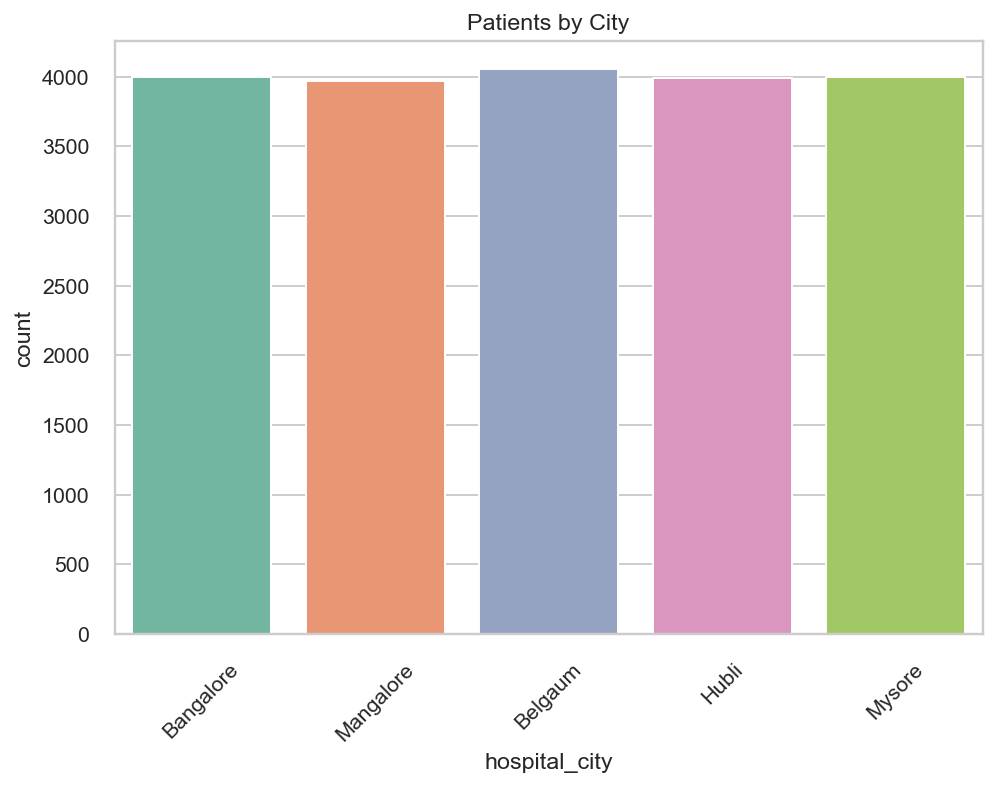

In [20]:
plt.figure()
sns.countplot(data=df, x='hospital_city', palette='Set2')
plt.title("Patients by City")
plt.xticks(rotation=45)
plt.show()

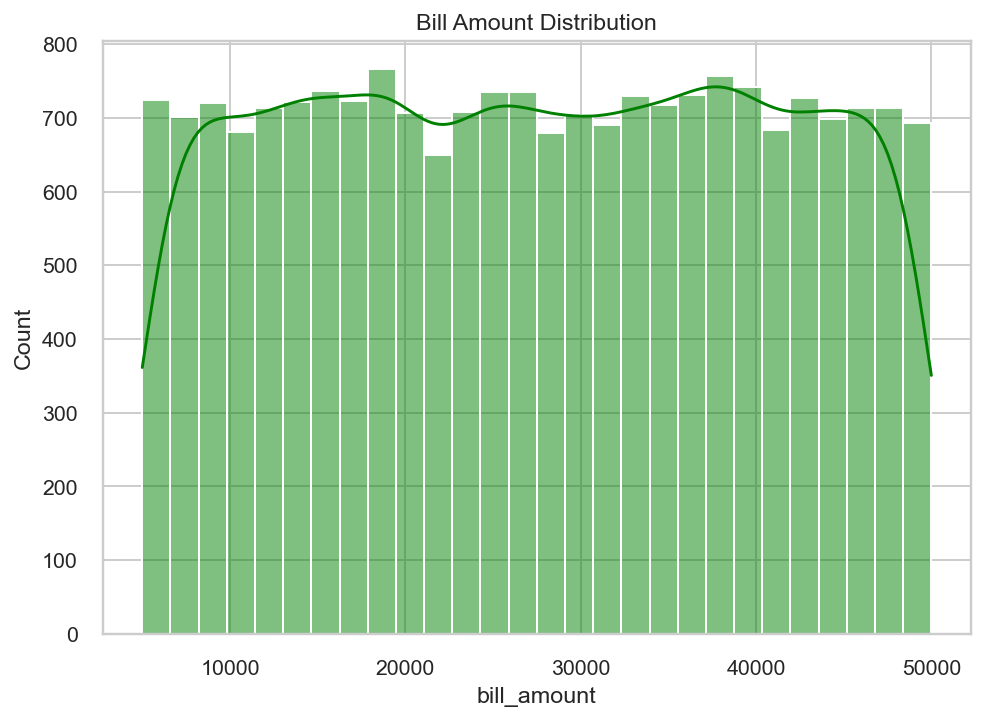

In [21]:
plt.figure()
sns.histplot(df['bill_amount'], kde=True, color='green')
plt.title("Bill Amount Distribution")
plt.show()

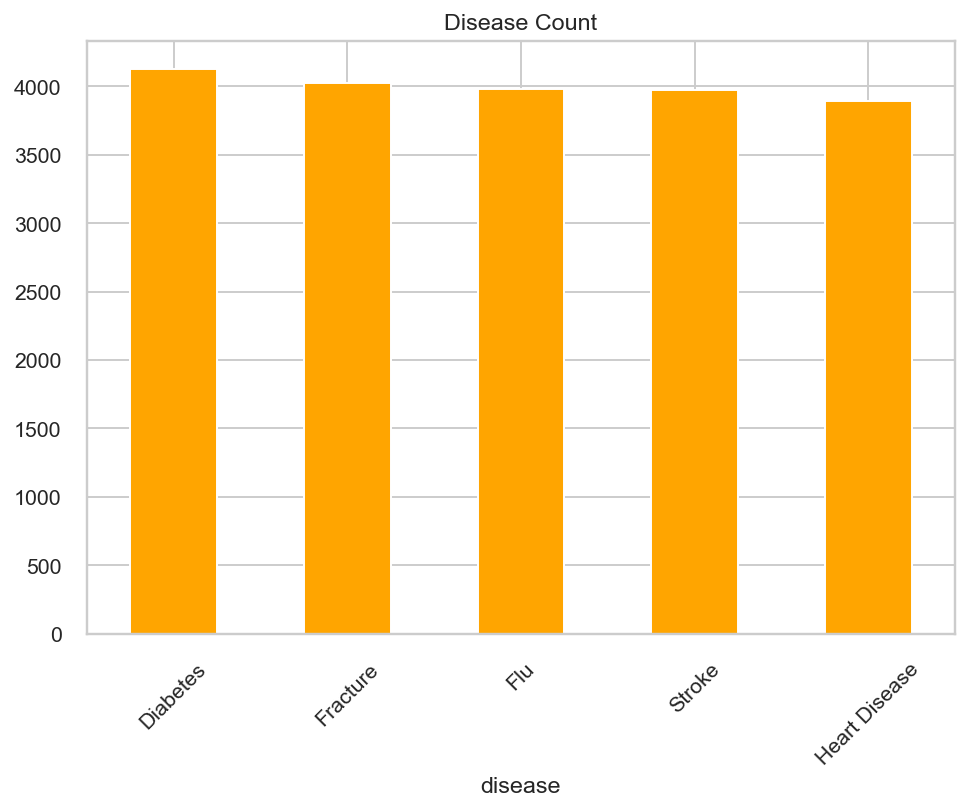

In [30]:
plt.figure()
df['disease'].value_counts().plot(kind='bar', color='orange')
plt.title("Disease Count")
plt.xticks(rotation=45)
plt.show()

C:\Users\BusinessComputers.in\AppData\Local\Temp\ipykernel_12132\2094883113.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='specialist', palette='coolwarm')


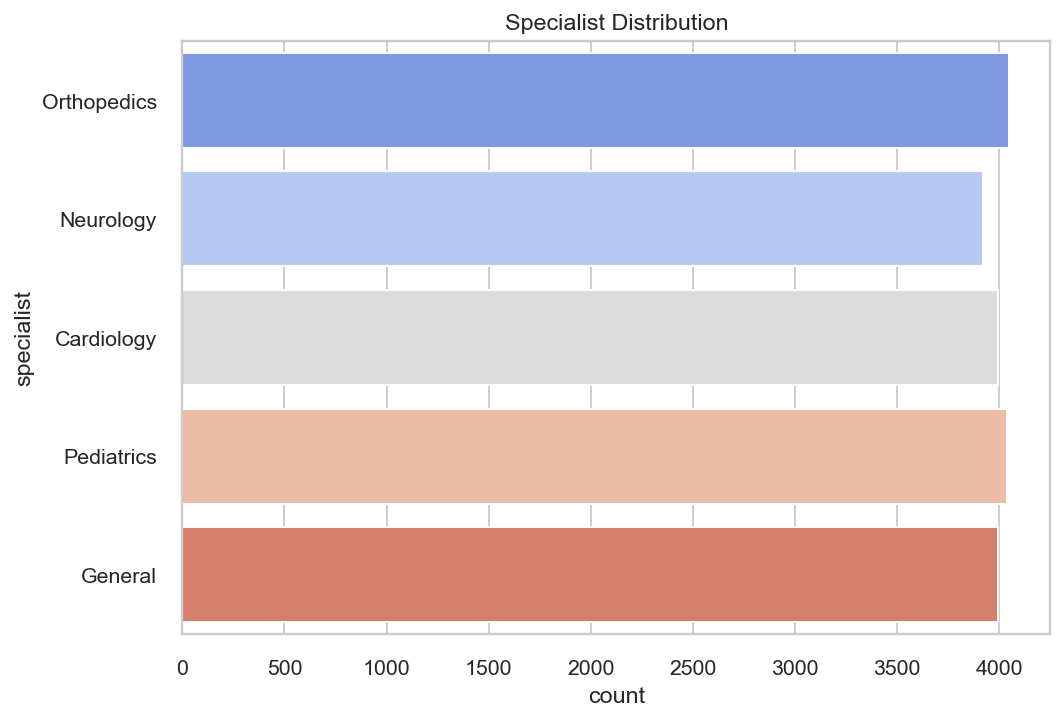

In [29]:
plt.figure()
sns.countplot(data=df, y='specialist', palette='coolwarm')
plt.title("Specialist Distribution")
plt.show()

C:\Users\BusinessComputers.in\AppData\Local\Temp\ipykernel_12132\3037084279.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='hospital_city', y='bill_amount', palette='Set3')


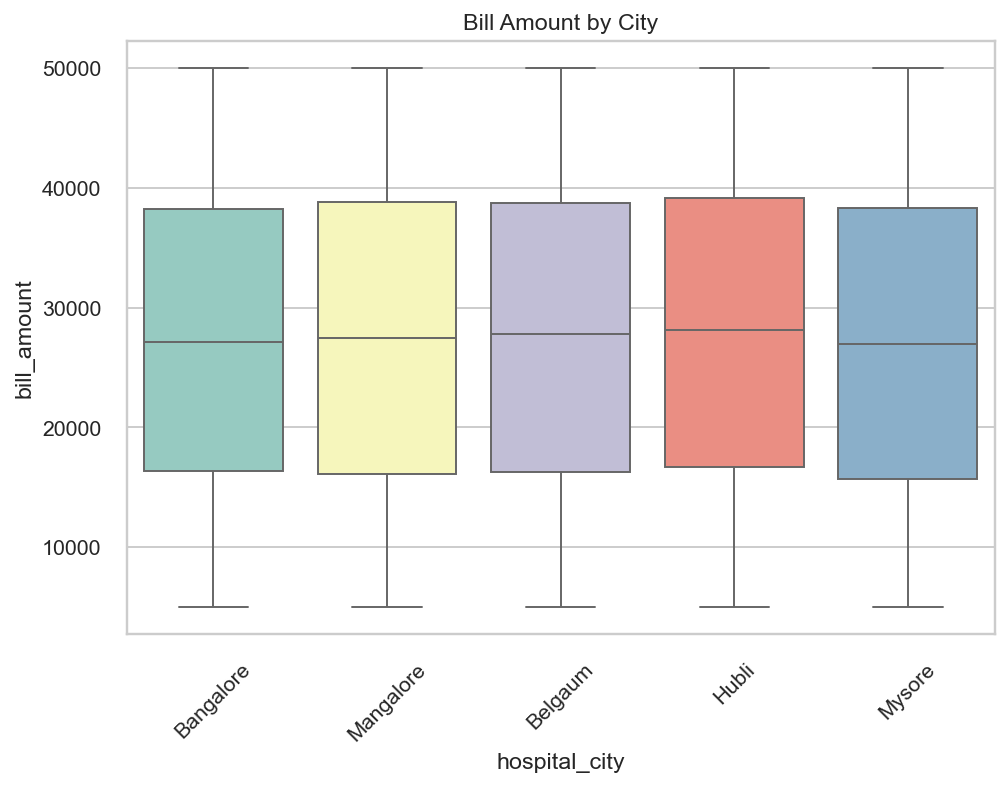

In [28]:
plt.figure()
sns.boxplot(data=df, x='hospital_city', y='bill_amount', palette='Set3')
plt.title("Bill Amount by City")
plt.xticks(rotation=45)
plt.show()

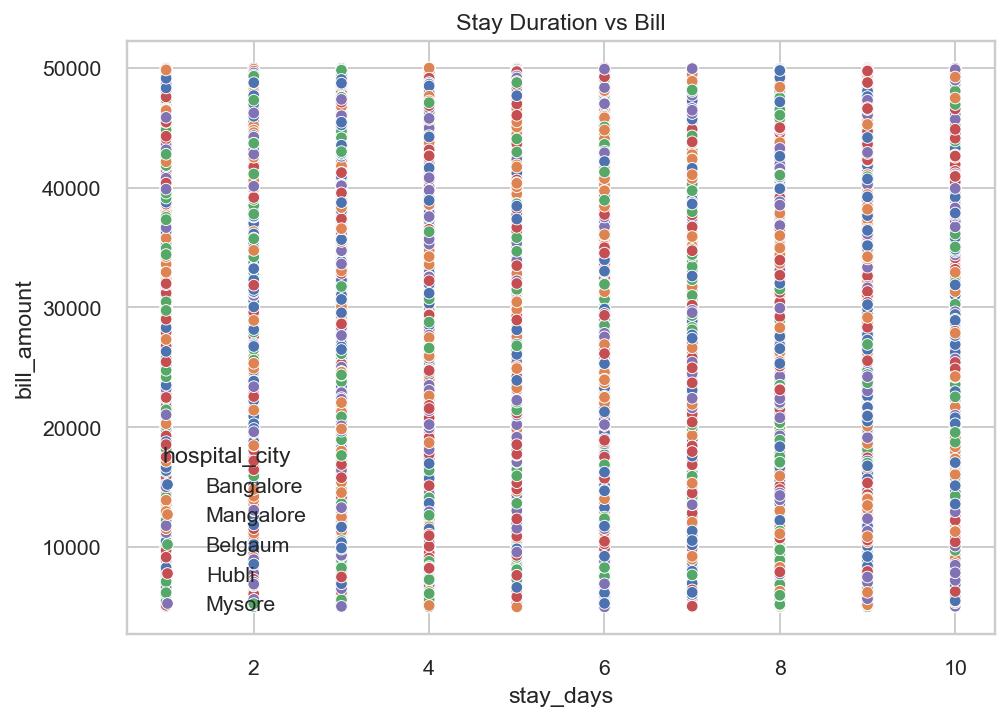

In [27]:
plt.figure()
sns.scatterplot(data=df, x='stay_days', y='bill_amount', hue='hospital_city')
plt.title("Stay Duration vs Bill")
plt.show()

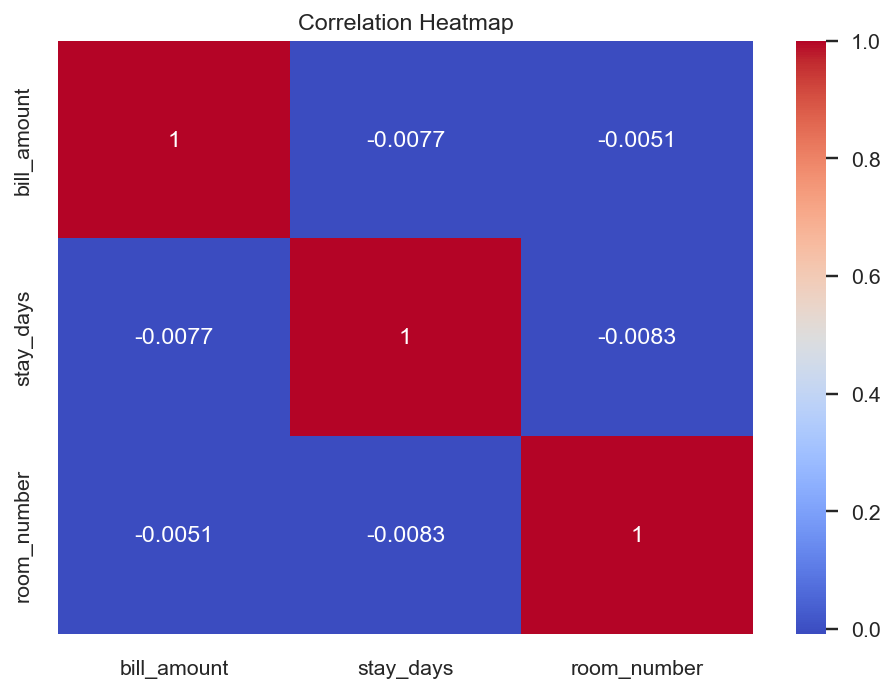

In [26]:
plt.figure()
corr = df[['bill_amount', 'stay_days', 'room_number']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

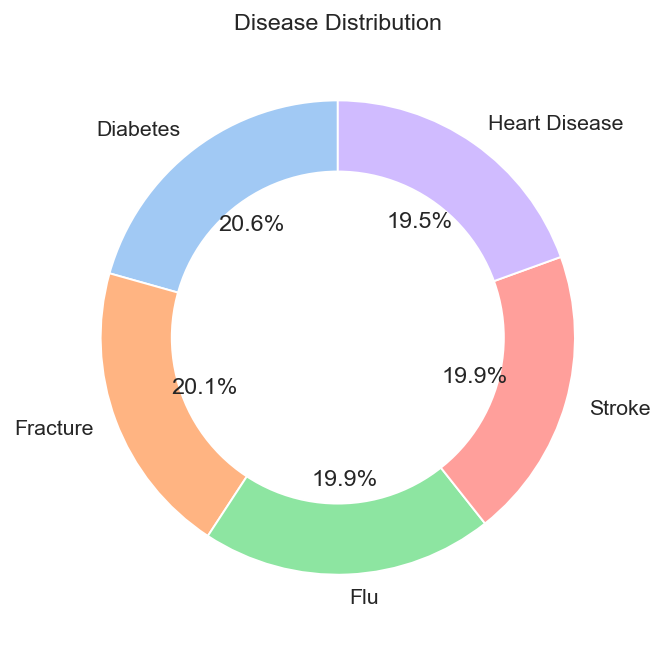

In [25]:
plt.figure()

disease_counts = df['disease'].value_counts()

plt.pie(
    disease_counts,
    labels=disease_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette("pastel")
)

# Donut hole
centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Disease Distribution")
plt.show()

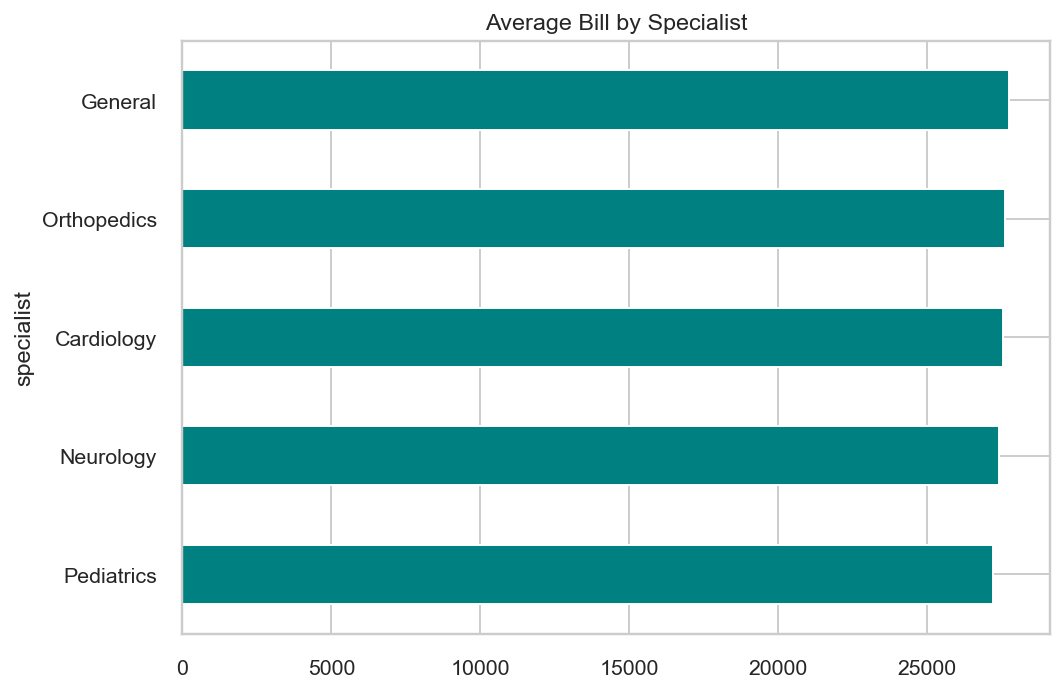

In [23]:
plt.figure()
df.groupby('specialist')['bill_amount'].mean().sort_values().plot(
    kind='barh', color='teal'
)
plt.title("Average Bill by Specialist")
plt.show()

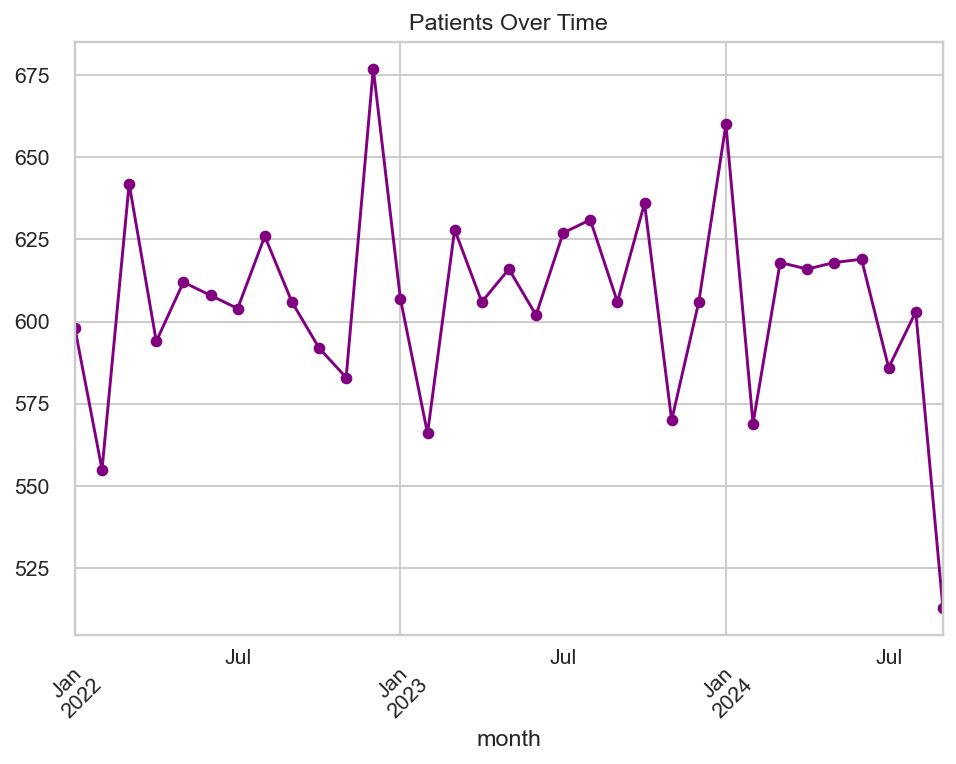

In [22]:
plt.figure()
monthly = df.groupby('month').size()

monthly.plot(marker='o', color='purple')
plt.title("Patients Over Time")
plt.xticks(rotation=45)
plt.show()